<a href="https://colab.research.google.com/github/nodan25/Summer_Traning_Projecs/blob/main/Project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Heart Disease Prediction Using Tree-Based Machine Learning Models***

# Objective

The objective of this project is to develop machine learning models that predict whether a patient is at risk of heart disease using medical information. The project compares a Decision Tree and a Random Forest classifier to evaluate their predictive performance and identifies the most important medical factors influencing heart disease risk.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


# Load a dataset using pandas
df=pd.read_csv('heart.csv')
df=pd.DataFrame(df)
df.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [14]:
# To getting all information of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [7]:
# To get the sum of null value
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [16]:
# for getting all detail
df.describe(include='all')

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [18]:
#  To checking duplicated values
df.duplicated().sum()

np.int64(1)

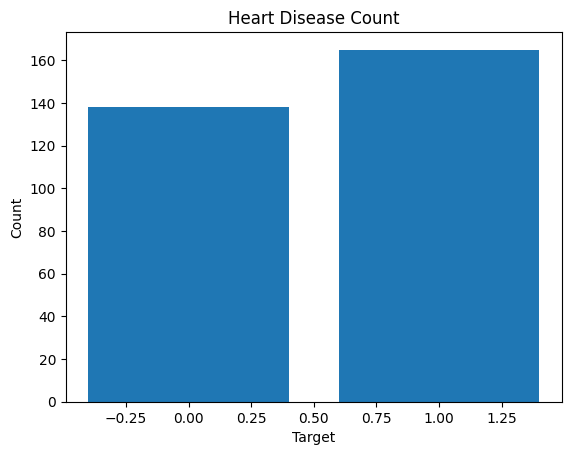

In [24]:
# For making a bar graph
s=df['target'].value_counts()
plt.bar(s.index ,s.values)
plt.xlabel('Target')
plt.ylabel('Count')
plt.title('Heart Disease Count')
plt.show()

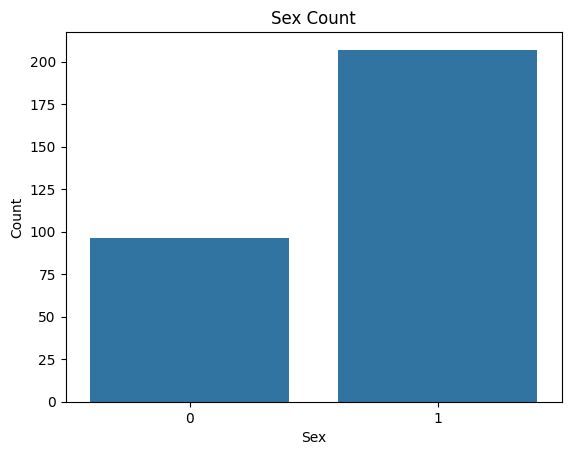

In [35]:
# graph for sex count
sns.countplot(x='sex',data=df)
plt.xlabel('Sex')
plt.ylabel('Count')
plt.title('Sex Count')
plt.show()

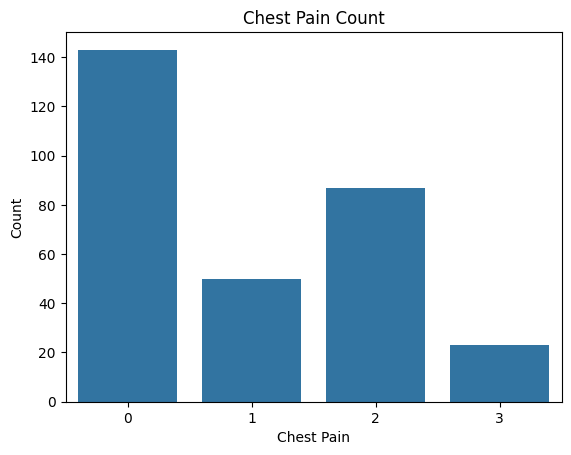

In [99]:
# bar graph for chest pain
sns.countplot(x='cp',data=df)
plt.xlabel('Chest Pain')
plt.ylabel('Count')
plt.title('Chest Pain Count')
plt.show()

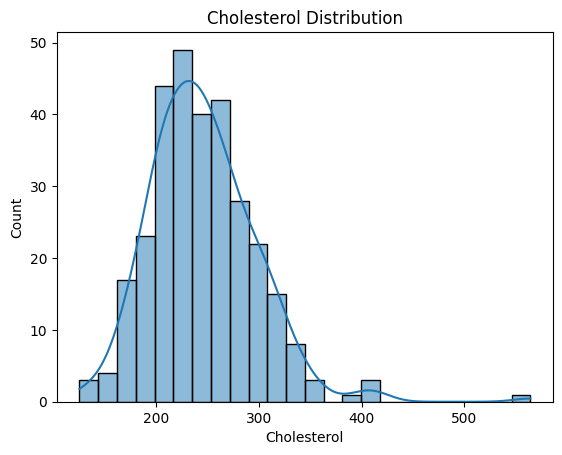

In [100]:
# histogram for cholesterol Distribution
sns.histplot(df['chol'],kde=True)
plt.xlabel('Cholesterol')
plt.ylabel('Count')
plt.title('Cholesterol Distribution')
plt.show()

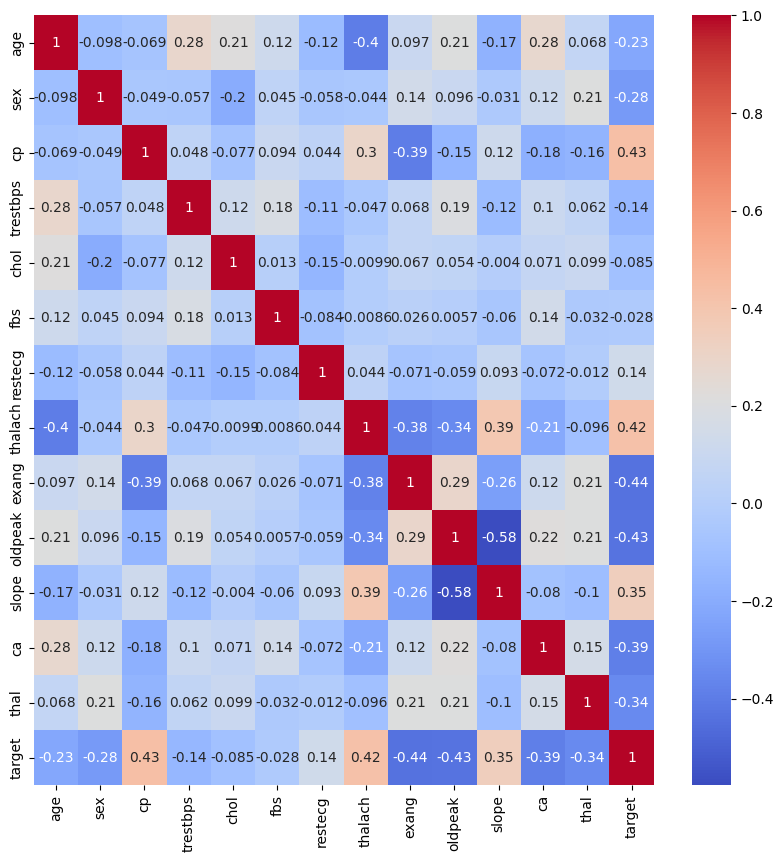

In [89]:
# To make a correlation between each data

le=LabelEncoder()
for columns in ['sex','cp','fbs','restecg','exang','slope','ca','thal','target']:
    df[columns]=le.fit_transform(df[columns])
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),annot=True , cmap='coolwarm')
plt.show()

In [41]:
# To seprate columns into x,y

x=df.drop('target',axis=1)
y=df['target']
print(x)
print(y)

     age  sex  cp  trestbps  chol  ...  exang  oldpeak  slope  ca  thal
0     63    1   3       145   233  ...      0      2.3      0   0     1
1     37    1   2       130   250  ...      0      3.5      0   0     2
2     41    0   1       130   204  ...      0      1.4      2   0     2
3     56    1   1       120   236  ...      0      0.8      2   0     2
4     57    0   0       120   354  ...      1      0.6      2   0     2
..   ...  ...  ..       ...   ...  ...    ...      ...    ...  ..   ...
298   57    0   0       140   241  ...      1      0.2      1   0     3
299   45    1   3       110   264  ...      0      1.2      1   0     3
300   68    1   0       144   193  ...      0      3.4      1   2     3
301   57    1   0       130   131  ...      1      1.2      1   1     3
302   57    0   1       130   236  ...      0      0.0      1   1     2

[303 rows x 13 columns]
0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target

In [44]:
# For getting train and test data

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(242, 13)
(61, 13)
(242,)
(61,)


In [47]:
# For making a DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
td=DecisionTreeClassifier()
td.fit(x_train, y_train)


DecisionTreeClassifier()

[Text(0.5733173076923077, 0.95, 'x[2] <= 0.5\ngini = 0.495\nsamples = 242\nvalue = [109, 133]'),
 Text(0.31490384615384615, 0.85, 'x[11] <= 0.5\ngini = 0.413\nsamples = 110\nvalue = [78, 32]'),
 Text(0.4441105769230769, 0.8999999999999999, 'True  '),
 Text(0.1875, 0.75, 'x[8] <= 0.5\ngini = 0.498\nsamples = 53\nvalue = [25, 28]'),
 Text(0.07692307692307693, 0.65, 'x[12] <= 2.5\ngini = 0.302\nsamples = 27\nvalue = [5, 22]'),
 Text(0.038461538461538464, 0.55, 'x[4] <= 316.5\ngini = 0.095\nsamples = 20\nvalue = [1, 19]'),
 Text(0.019230769230769232, 0.45, 'gini = 0.0\nsamples = 18\nvalue = [0, 18]'),
 Text(0.057692307692307696, 0.45, 'x[9] <= 0.6\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.038461538461538464, 0.35, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.07692307692307693, 0.35, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.11538461538461539, 0.55, 'x[6] <= 0.5\ngini = 0.49\nsamples = 7\nvalue = [4, 3]'),
 Text(0.09615384615384616, 0.45, 'gini = 0.0\nsamples = 3\

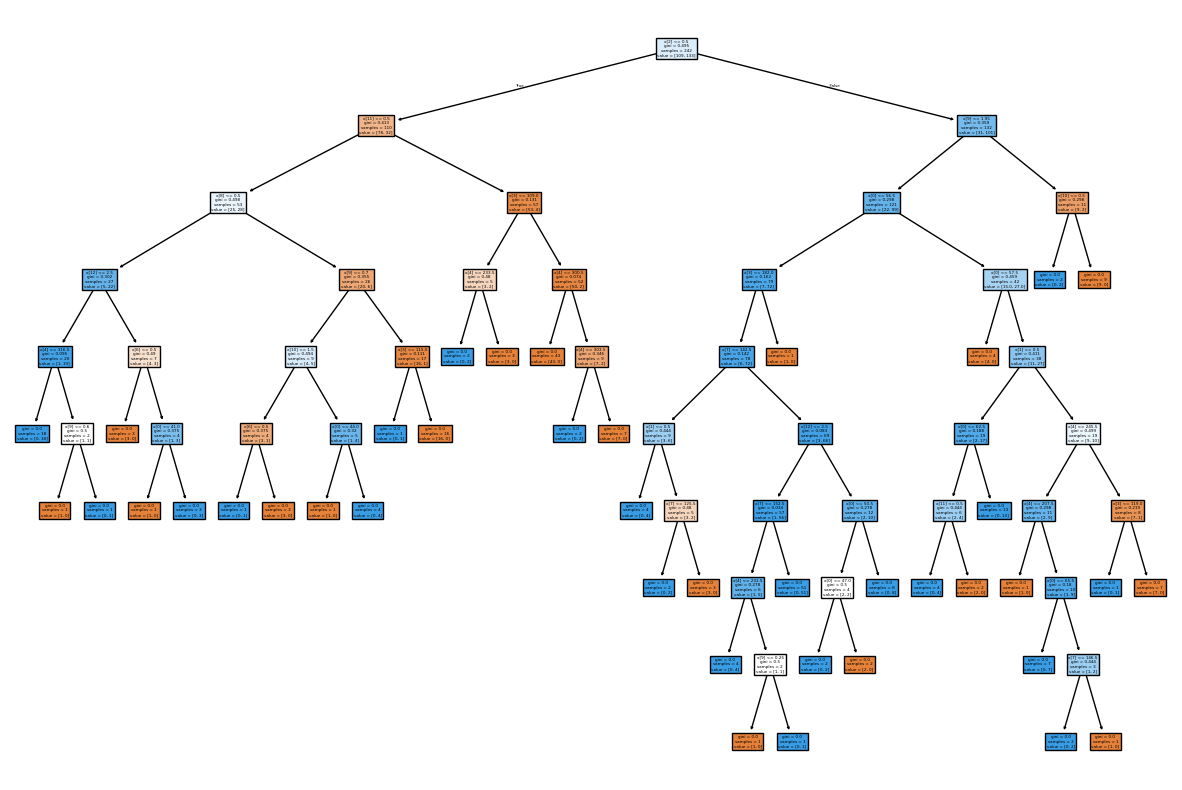

In [58]:
# for making a tree

from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(td , filled=True)

In [95]:
from sklearn.metrics import accuracy_score ,confusion_matrix ,precision_score , recall_score , f1_score
y_pred=td.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy: ",accuracy)


# to get confusion_matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion_matrix :" ,cm)


# For getting precision_score
precision = precision_score(y_test, y_pred)

print("Precision:", precision)


# For getting recall_score
recall = recall_score(y_test, y_pred)

print("Recall:", recall)



# Getting F1_score
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)



#  To predict for some value
td.predict([[63,1,3,145,233,1,0,150,0,2.3,0,0,1]])

Accuracy:  0.8524590163934426
Confusion_matrix : [[27  2]
 [ 7 25]]
Precision: 0.9259259259259259
Recall: 0.78125
F1 Score: 0.847457627118644


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [64]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(x_train,y_train)

RandomForestClassifier()

In [97]:
from sklearn.metrics import accuracy_score ,confusion_matrix ,precision_score , recall_score , f1_score
rf_pred=rf.predict(x_test)
accuracy=accuracy_score(y_test,rf_pred)
print("Accuracy :" , accuracy)

# to get confusion_matrix
cm = confusion_matrix(y_test, rf_pred)

print("Confusion_matrix :" ,cm)


# For getting precision_score
precision = precision_score(y_test, rf_pred)

print("Precision:", precision)


# For getting recall_score
recall = recall_score(y_test, rf_pred)

print("Recall:", recall)



# Getting F1_score
f1 = f1_score(y_test, rf_pred)

print("F1 Score:", f1)



#  To predict for some value
rf.predict([[63,1,3,145,233,1,0,150,0,2.3,0,0,1]])

Accuracy : 0.8360655737704918
Confusion_matrix : [[24  5]
 [ 5 27]]
Precision: 0.84375
Recall: 0.84375
F1 Score: 0.84375


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([1])

In [98]:
# For making a comparision table

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Decision Tree": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ],
    "Random Forest": [
        accuracy_score(y_test, rf_pred),
        precision_score(y_test, rf_pred),
        recall_score(y_test, rf_pred),
        f1_score(y_test, rf_pred)
    ]
})

comparison

,Metric,Decision Tree,Random Forest
0,Accuracy,0.852459,0.836066
1,Precision,0.925926,0.843750
2,Recall,0.781250,0.843750
3,F1-Score,0.847458,0.843750
